# "Machine Learning \& Deep Learning Applications in Modern Power Systems"
## Department of Electrical Engineering - PMEC, Berhampur
### Instructor: Dr. Suryalok Dash

# Day 11,12: Exercise Notebook
**Task:** Complete the missing code sections marked with `### YOUR CODE HERE ###`.

In [1]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

# Synthetic Solar Power data (1000 hours). Drops to 0 at night.
np.random.seed(15)
time_solar = np.arange(1000)
solar_power = np.clip(50 * np.sin(2 * np.pi * time_solar / 24 - np.pi/2) + np.random.normal(0, 5, 1000), 0, None)

# Task 1: Create a Pandas DataFrame named 'df_solar' with a column named 'Power_kW'
df_solar = pd.DataFrame({"Power_kW": solar_power})

# Task 2: Split 'df_solar' into 'train_df' (first 800 rows) and 'test_df' (remaining rows).
train_df = df_solar.iloc[:800]
test_df = df_solar.iloc[800:]

# Task 3: Initialize a MinMaxScaler, fit it on 'train_df', and transform both train and test sets.
scaler = MinMaxScaler()
train_scaled = scaler.fit_transform(train_df)
test_scaled = scaler.transform(test_df)

In [2]:
def create_tabular_data(data, lags):
    X, y = [], []
    for i in range(len(data) - lags):
        X.append(data[i:i+lags, 0])
        y.append(data[i+lags, 0])
    return np.array(X), np.array(y)

# Task 4: Use 'create_tabular_data' to create X_train_base and y_train_base using a lag of 2 hours.
X_train_base, y_train_base = create_tabular_data(train_scaled, lags=2)

# Task 5: Create X_test_base and y_test_base using the same lag of 2 hours on 'test_scaled'.
X_test_base, y_test_base = create_tabular_data(test_scaled, lags=2)

# Task 6: Print the shape of X_train_base to confirm it has 2 features.
print("Base Features Shape:", X_train_base.shape)

Base Features Shape: (798, 2)


In [3]:
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error

# Task 7: Initialize an SVR model with kernel='rbf' and C=1.0. Name it 'base_svr'.
base_svr = SVR(kernel="rbf", C=1.0)

# Task 8: Fit 'base_svr' using X_train_base and y_train_base.
base_svr.fit(X_train_base, y_train_base)

# Task 9: Predict on X_test_base. Calculate and print the Mean Squared Error against y_test_base.
base_preds = base_svr.predict(X_test_base)
base_mse = mean_squared_error(y_test_base, base_preds)
print(f"Base SVR MSE: {base_mse:.4f}")

Base SVR MSE: 0.0115


In [4]:
# Task 10: Let's capture the daily cycle. Create a new dataset using a lag of 24 hours.
# Use 'create_tabular_data' on train_scaled with lags=24.
X_train_mod, y_train_mod = create_tabular_data(train_scaled, lags=24)

# Task 11: Create the modified test set using a lag of 24 hours on test_scaled.
X_test_mod, y_test_mod = create_tabular_data(test_scaled, lags=24)

# Task 12: Train a NEW SVR model named 'mod_svr' using the new 24-lag training data.
mod_svr = SVR(kernel="rbf", C=1.0)
mod_svr.fit(X_train_mod, y_train_mod)

SVR()

Modified SVR MSE (24-hour lag): 0.0058


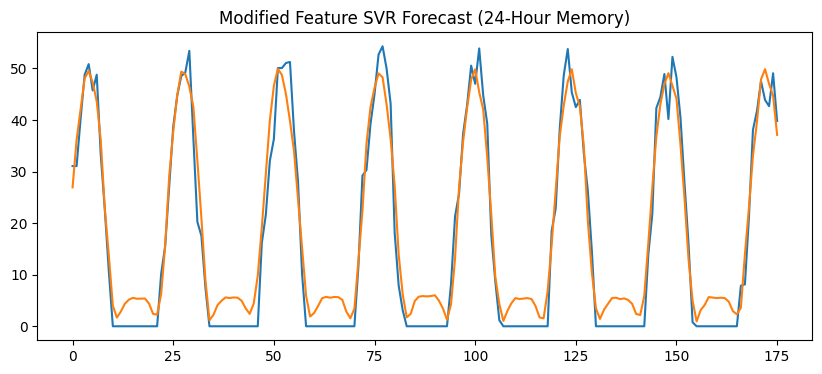

In [5]:
import matplotlib.pyplot as plt

# Task 13: Predict using the 'mod_svr' model on 'X_test_mod'. Calculate the new MSE.
mod_preds = mod_svr.predict(X_test_mod)
mod_mse = mean_squared_error(y_test_mod, mod_preds)
print(f"Modified SVR MSE (24-hour lag): {mod_mse:.4f}")

# Task 14: Inverse transform both 'base_preds' and 'mod_preds' to get actual kW values.
# Note: Ensure you reshape arrays properly if required by the scaler.
base_preds_kw = scaler.inverse_transform(base_preds.reshape(-1, 1))
mod_preds_kw = scaler.inverse_transform(mod_preds.reshape(-1, 1))

# Task 15: Plot the actual test power (y_test_mod inversely transformed) against 'mod_preds_kw'.
actual_kw = scaler.inverse_transform(y_test_mod.reshape(-1, 1))

plt.figure(figsize=(10, 4))
plt.plot(actual_kw, label="Actual Power") # plot actual
plt.plot(mod_preds_kw, label="Predicted Power") # plot predicted
plt.title("Modified Feature SVR Forecast (24-Hour Memory)")
plt.show()